# Адаптивный выбор направления для жадных и случайных квазиньютоновских методов
### Курсовая работа — 3 курс, Прикладной анализ данных и ИИ

**Реализованные методы:**
- BFGS (эталон, implicit), L-BFGS (scipy)
- GrBFGSv1, RaBFGSv2 — базовые explicit методы (Lin et al., 2022)
- **EpsGreedySelector** (новый): exponential / polynomial / gradient-adaptive расписания
- **AdaptiveRankSelector** (новый): eq.22 с адаптивным рангом r  
- **CurvatureSelector, StepSizeSelector, GradCosineSelector, CombinedSelector** (новые): переключение на основе качества шага


**Датасеты:** синтетика, w8a (logistic regression), E2006 (ridge regression), sklearn digits (MLP)

## 1. Импорты

In [1]:
import numpy as np
from numpy.linalg import norm, eigvalsh, eigh, inv, solve
import scipy, scipy.special
from scipy.optimize import line_search, minimize
from scipy.sparse import diags, issparse
from collections import defaultdict
import time, warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.datasets import load_svmlight_file, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path

print("Imports OK")

Imports OK


## 2. Оракулы

In [2]:
class BaseSmoothOracle:
    def func(self, x): raise NotImplementedError
    def grad(self, x): raise NotImplementedError
    def hess(self, x): raise NotImplementedError


class QuadraticOracle(BaseSmoothOracle):
    """func(x) = 0.5 x^T A x - b^T x.  Hessian = A (constant)."""
    def __init__(self, A, b): self.A=np.array(A,dtype=float); self.b=np.array(b,dtype=float)
    def func(self, x): return 0.5*x@self.A@x - self.b@x
    def grad(self, x): return self.A@x - self.b
    def hess(self, x): return self.A


class LogRegL2Oracle(BaseSmoothOracle):
    """
    Oracle for logistic regression with l2 regularization:
         func(x) = 1/m sum_i log(1 + exp(-b_i * a_i^T x)) + regcoef / 2 ||x||_2^2.

    Let A and b be parameters of the logistic regression (feature matrix
    and labels vector respectively).
    """
    def __init__(self, A, b, regcoef):
        self.matvec_Ax = lambda x: A@x
        self.matvec_ATx = lambda x: A.T@x
        self.matmat_ATsA = lambda x: A.T @ x @ A
        self.b = b
        self.regcoef = regcoef

    def func(self, x):
        m = self.b.shape[0]
        return np.dot(np.ones(m), np.logaddexp(0, -self.b * (self.matvec_Ax(x))))/m + self.regcoef*np.dot(x, x)/2

    def grad(self, x):
        m = self.b.shape[0]
        return -self.matvec_ATx(self.b * scipy.special.expit(-self.b*self.matvec_Ax(x)))/m + self.regcoef*x

    def hess(self, x):
        m = self.b.shape[0]
        return self.matmat_ATsA(diags(scipy.special.expit(-self.b*self.matvec_Ax(x))*scipy.special.expit(self.b*self.matvec_Ax(x))))/m + self.regcoef*np.eye(x.shape[0])


class RidgeRegressionOracle(BaseSmoothOracle):
    """func(x)=1/(2m)||Ax-b||^2 + reg/2||x||^2.  Constant Hessian."""
    def __init__(self, A, b, regcoef):
        self._A=A; self._b=b; self.regcoef=regcoef; m=A.shape[0]
        self._H=A.T@A/m+regcoef*np.eye(A.shape[1]); self._g0=A.T@b/m
    def func(self, x): r=self._A@x-self._b; return 0.5*r@r/len(self._b)+0.5*self.regcoef*x@x
    def grad(self, x): return self._H@x - self._g0
    def hess(self, x): return self._H


class MLPOracle(BaseSmoothOracle):
    """
    2-слойный MLP: d_in → hidden → n_cls (softmax, cross-entropy + L2).
    Параметры w = [W1.ravel(), b1, W2.ravel(), b2].
    Gradient — точный backprop; Hessian — конечные разности (O(d·n) на итерацию).
    Практично при d <= 1000, n <= 500.
    """
    def __init__(self, X, y, hidden=8, regcoef=1e-3, fd_eps=1e-5):
        self.X=np.array(X,dtype=float); self.y=np.array(y,dtype=int)
        self.n,self.d_in=self.X.shape; self.hidden=hidden
        self.n_cls=len(np.unique(y)); self.regcoef=regcoef; self.fd_eps=fd_eps
        self._shapes=[(self.d_in,hidden),(hidden,),(hidden,self.n_cls),(self.n_cls,)]
        self.d=sum(int(np.prod(s)) for s in self._shapes)
        self._cache={}

    def _unpack(self, w):
        idx,ps=[],[] ; i=0
        for sh in self._shapes:
            sz=int(np.prod(sh)); ps.append(w[i:i+sz].reshape(sh)); i+=sz
        return ps

    def _forward(self, w, X=None):
        if X is None: X=self.X
        W1,b1,W2,b2=self._unpack(w)
        A1=np.tanh(X@W1+b1); Z2=A1@W2+b2
        Z2-=Z2.max(axis=1,keepdims=True); eZ=np.exp(Z2)
        return A1, eZ/eZ.sum(axis=1,keepdims=True)

    def func(self, w):
        _,P=self._forward(w)
        return -np.log(P[np.arange(self.n),self.y]+1e-12).mean()+0.5*self.regcoef*w@w

    def grad(self, w):
        W1,b1,W2,b2=self._unpack(w); A1,P=self._forward(w)
        dZ2=P.copy(); dZ2[np.arange(self.n),self.y]-=1; dZ2/=self.n
        dW2=A1.T@dZ2; db2=dZ2.sum(0)
        dZ1=(dZ2@W2.T)*(1-A1**2)
        dW1=self.X.T@dZ1; db1=dZ1.sum(0)
        return np.concatenate([dW1.ravel(),db1,dW2.ravel(),db2])+self.regcoef*w

    def hess(self, w):
        key=w.tobytes()
        if key in self._cache: return self._cache[key]
        d=len(w); h=self.fd_eps; g0=self.grad(w); H=np.zeros((d,d))
        for i in range(d):
            ei=np.zeros(d); ei[i]=h; H[:,i]=(self.grad(w+ei)-g0)/h
        H=(H+H.T)/2
        if len(self._cache)>2: self._cache.clear()
        self._cache[key]=H; return H

    def accuracy(self, w, X=None, y=None):
        if X is None: X=self.X
        if y is None: y=self.y
        _,P=self._forward(w,X); return np.mean(P.argmax(axis=1)==y)

    def random_init(self, scale=0.05, seed=None):
        return np.random.default_rng(seed).standard_normal(self.d)*scale

## 3. Вспомогательные функции

In [3]:
class search_alpha:
    """Armijo-Wolfe line search with backtracking fallback."""
    def __init__(self,c1=1e-4,c2=0.9): self.c1=c1; self.c2=c2
    def backtracking(self,oracle,xk,dk):
        a=1.0; f0=oracle.func(xk); dg=oracle.grad(xk)@dk
        for _ in range(60):
            if oracle.func(xk+a*dk)<=f0+a*self.c1*dg: break
            a/=2
        return a
    def search(self,oracle,xk,dk):
        r=line_search(oracle.func,oracle.grad,xk,dk,c1=self.c1,c2=self.c2)[0]
        return r if r is not None else self.backtracking(oracle,xk,dk)


def randomized_top_eigs(A, rank, n_oversampling=5, rng=None):
    """Randomized top-r eigenpairs. Cost O(d^2·rank). Returns V(d×rank), lam(rank,)."""
    if rng is None: rng=np.random.default_rng(0)
    d=A.shape[0]; k=min(rank+n_oversampling,d)
    Q,_=np.linalg.qr(A@rng.standard_normal((d,k)))
    B=Q.T@A@Q; lam,V=np.linalg.eigh(B); idx=np.argsort(lam)[::-1][:rank]
    return Q@V[:,idx], np.maximum(lam[idx],1e-14)


def compute_sigma_A(L, A):
    """
    σ_A(G_k) = tr(G_k A^{-1}) - log det(G_k A^{-1}) - d  ≥ 0
    G_k^{-1} = L^T L.
    Вычисляется через собственные числа A^{1/2} G_k^{-1} A^{1/2}.
    """
    d=A.shape[0]
    ev_A,V_A=np.linalg.eigh(A); ev_A=np.maximum(ev_A,1e-14)
    A_sqrt=V_A@np.diag(np.sqrt(ev_A))@V_A.T
    M=A_sqrt@(L.T@L)@A_sqrt; ev_M=np.maximum(np.linalg.eigvalsh(M),1e-14)
    lam=np.maximum(1./ev_M,1e-14)
    return float(np.sum(lam)-np.sum(np.log(lam))-d)

## 4. Модульные селекторы направлений

```
BaseSelector
├── RandomSelector           — RaBFGSv2: ũ ~ Unif(S^{d-1})
├── GreedyV1Selector         — GrBFGSv1 (eq.9): i* = argmax u_i^T A u_i
├── EpsGreedySelector        — ε-жадный (новый)
│   ├── 'exponential'          ε_k = ε₀ cᵏ
│   ├── 'polynomial'           ε_k = ε₀/(1+k/T)
│   └── 'gradient_adaptive'    ε_k = ε₀(‖g_k‖/‖g₀‖)^α
├── AdaptiveRankSelector     — eq.22 + rSVD + адаптивный r (новый)
├── CurvatureSelector        — ε_k по кривизне y^T s/‖s‖² (новый)
├── StepSizeSelector         — ε_k по размеру шага α_k (новый)
├── GradCosineSelector       — ε_k по cos(g_k, g_{k-1}) (новый)
└── CombinedSelector         — взвешенное объединение трёх (новый)
```

In [4]:
class BaseSelector:
    needs_linv = False
    def setup(self, n, rng): self.n = n
    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        raise NotImplementedError


class RandomSelector(BaseSelector):
    needs_linv = False
    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        n=L.shape[0]; tu=rng.standard_normal(n); nm=norm(tu)
        return tu/(nm if nm>1e-16 else 1.0)


class GreedyV1Selector(BaseSelector):
    """GrBFGSv1 (eq.9): i* = argmax_i (L^T e_i)^T A (L^T e_i).  O(d^2)."""
    needs_linv = False
    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        n=L.shape[0]; scores=np.einsum('ij,ij->j',L.T,A@L.T)
        tu=np.zeros(n); tu[int(np.argmax(scores))]=1.0; return tu


class EpsGreedySelector(BaseSelector):
    """
    ε-жадный: с вероятностью ε_k — random (exploration), иначе — greedy (exploitation).

    Расписания убывания ε_k:
      'exponential'        ε_k = ε₀ · c^k
      'polynomial'         ε_k = ε₀ / (1 + k/T)
      'constant'           ε_k = ε₀
      'gradient_adaptive'  ε_k = ε₀ · (‖g_k‖/‖g₀‖)^α   [α = параметр c]
    """
    def __init__(self, eps_0=0.5, decay='exponential', c=0.95, T=50,
                 greedy_sel=None, random_sel=None):
        self.eps_0=eps_0; self.decay=decay; self.c=c; self.T=T
        self.greedy_sel=greedy_sel or GreedyV1Selector()
        self.random_sel=random_sel or RandomSelector()

    @property
    def needs_linv(self):
        return self.greedy_sel.needs_linv or self.random_sel.needs_linv

    def setup(self, n, rng):
        self.greedy_sel.setup(n,rng); self.random_sel.setup(n,rng)
        self.eps_history=[]; self.choice_history=[]

    def get_eps(self, k, gn=None, gn0=None):
        if self.decay=='exponential':    return self.eps_0*(self.c**k)
        elif self.decay=='polynomial':   return self.eps_0/(1.0+k/max(self.T,1))
        elif self.decay=='constant':     return self.eps_0
        elif self.decay=='gradient_adaptive':
            if gn is None or gn0 is None or gn0<1e-14: return self.eps_0
            return self.eps_0*(gn/gn0)**self.c
        raise ValueError(self.decay)

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        eps_k=self.get_eps(k,grad_norm,grad_norm_0); self.eps_history.append(eps_k)
        kw=dict(Linv=Linv,grad_norm=grad_norm,grad_norm_0=grad_norm_0,step_info=step_info)
        if rng.random()<eps_k:
            self.choice_history.append('R'); return self.random_sel.select(L,A,k,rng,**kw)
        self.choice_history.append('G'); return self.greedy_sel.select(L,A,k,rng,**kw)


class AdaptiveRankSelector(BaseSelector):
    """
    Partial Greedy (eq.22) с адаптивным рангом r. Нужен Linv.

    scores[i] ≈ ‖Λ_r^{-1/2} V_r^T Linv[:,i]‖²   (eq.22 с ранг-r аппроксимацией A^{-1})

    Адаптация ранга:
      ratio = ‖g_k‖/‖g_{k-1}‖
      > θ     → медленный прогресс → r += 1
      < θ^3   → быстрый прогресс  → r -= 1
    """
    needs_linv = True
    def __init__(self, r_min=1, r_max=10, theta=0.99, n_over=5):
        self.r_min=r_min; self.r_max=r_max; self.theta=theta; self.n_over=n_over

    def setup(self, n, rng):
        self.current_rank=self.r_min; self.prev_gn=None; self.rank_history=[]

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        if self.prev_gn is not None and grad_norm is not None:
            r=grad_norm/(self.prev_gn+1e-14)
            if r>self.theta:    self.current_rank=min(self.current_rank+1,self.r_max)
            elif r<self.theta**3: self.current_rank=max(self.current_rank-1,self.r_min)
        self.prev_gn=grad_norm; self.rank_history.append(self.current_rank)
        n=L.shape[0]; rank=min(self.current_rank,n)
        Vr,lr=randomized_top_eigs(A,rank=rank,n_oversampling=self.n_over,rng=rng)
        M=Vr.T@Linv; sc=np.sum((M/np.sqrt(lr)[:,None])**2,axis=0)
        tu=np.zeros(n); tu[int(np.argmax(sc))]=1.0; return tu


class CurvatureSelector(BaseSelector):
    """
    Переключение по кривизне ρ_k = y_k^T s_k / ‖s_k‖².

    Если ρ_k сильно отклоняется от ρ_threshold → плохое приближение → exploration.
    ε_k = eps_max · σ(β · |log(ρ_k/ρ_thr)|  - 1)
    """
    def __init__(self, eps_max=0.8, rho_thr=1.0, beta=2.0,
                 greedy_sel=None, random_sel=None):
        self.eps_max=eps_max; self.rho_thr=rho_thr; self.beta=beta
        self.greedy_sel=greedy_sel or GreedyV1Selector()
        self.random_sel=random_sel or RandomSelector()
        self.eps_history=[]; self.rho_history=[]

    @property
    def needs_linv(self): return self.greedy_sel.needs_linv or self.random_sel.needs_linv

    def setup(self, n, rng):
        self.greedy_sel.setup(n,rng); self.random_sel.setup(n,rng)
        self.eps_history=[]; self.rho_history=[]

    def _eps(self, step_info):
        s=(step_info or {}).get('s'); y=(step_info or {}).get('y')
        if s is None or y is None: return self.eps_max/2
        ss=np.dot(s,s)
        if ss<1e-14: return self.eps_max/2
        rho=np.dot(y,s)/ss; self.rho_history.append(rho)
        dev=abs(np.log(max(rho,1e-6))-np.log(self.rho_thr))
        return float(np.clip(self.eps_max/(1+np.exp(-self.beta*(dev-1))),0,self.eps_max))

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        eps_k=self._eps(step_info); self.eps_history.append(eps_k)
        kw=dict(Linv=Linv,grad_norm=grad_norm,step_info=step_info)
        if rng.random()<eps_k: return self.random_sel.select(L,A,k,rng,**kw)
        return self.greedy_sel.select(L,A,k,rng,**kw)


class StepSizeSelector(BaseSelector):
    """
    Переключение по размеру шага α_k.

    α_k ≈ 1 (Newton-like) → G_k хороший → exploit.
    α_k << 1 → много бэктрекинга → G_k плохой → explore.
    ε_k = eps_max · (1 - min(α_k/α_ref, 1))
    """
    def __init__(self, eps_max=0.8, alpha_ref=0.5, greedy_sel=None, random_sel=None):
        self.eps_max=eps_max; self.alpha_ref=alpha_ref
        self.greedy_sel=greedy_sel or GreedyV1Selector()
        self.random_sel=random_sel or RandomSelector()
        self.eps_history=[]

    @property
    def needs_linv(self): return self.greedy_sel.needs_linv or self.random_sel.needs_linv

    def setup(self, n, rng):
        self.greedy_sel.setup(n,rng); self.random_sel.setup(n,rng); self.eps_history=[]

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        alpha=(step_info or {}).get('alpha', self.alpha_ref)
        eps_k=self.eps_max*(1.0-min(alpha/self.alpha_ref,1.0)); self.eps_history.append(eps_k)
        kw=dict(Linv=Linv,grad_norm=grad_norm,step_info=step_info)
        if rng.random()<eps_k: return self.random_sel.select(L,A,k,rng,**kw)
        return self.greedy_sel.select(L,A,k,rng,**kw)


class GradCosineSelector(BaseSelector):
    """
    Переключение по углу между градиентами.

    cos θ_k = g_k^T g_{k-1}/(‖g_k‖‖g_{k-1}‖)
    cos < 0 → осцилляция → explore.   ε_k = eps_max · max(0, -cos θ_k)
    """
    def __init__(self, eps_max=0.8, greedy_sel=None, random_sel=None):
        self.eps_max=eps_max
        self.greedy_sel=greedy_sel or GreedyV1Selector()
        self.random_sel=random_sel or RandomSelector()
        self.eps_history=[]; self.cos_history=[]

    @property
    def needs_linv(self): return self.greedy_sel.needs_linv or self.random_sel.needs_linv

    def setup(self, n, rng):
        self.greedy_sel.setup(n,rng); self.random_sel.setup(n,rng)
        self.eps_history=[]; self.cos_history=[]

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        gc=(step_info or {}).get('current_grad'); gp=(step_info or {}).get('prev_grad')
        cos_k=0.0
        if gc is not None and gp is not None:
            n1,n2=norm(gc),norm(gp)
            if n1>1e-14 and n2>1e-14: cos_k=np.dot(gc,gp)/(n1*n2)
        self.cos_history.append(cos_k)
        eps_k=self.eps_max*max(0.0,-cos_k); self.eps_history.append(eps_k)
        kw=dict(Linv=Linv,grad_norm=grad_norm,step_info=step_info)
        if rng.random()<eps_k: return self.random_sel.select(L,A,k,rng,**kw)
        return self.greedy_sel.select(L,A,k,rng,**kw)


class CombinedSelector(BaseSelector):
    """Взвешенное объединение трёх step-quality критериев."""
    def __init__(self, eps_max=0.9, w1=0.4, w2=0.3, w3=0.3,
                 rho_thr=1.0, alpha_ref=0.5, greedy_sel=None, random_sel=None):
        self.eps_max=eps_max; self.w1=w1; self.w2=w2; self.w3=w3
        self.rho_thr=rho_thr; self.alpha_ref=alpha_ref
        self.greedy_sel=greedy_sel or GreedyV1Selector()
        self.random_sel=random_sel or RandomSelector()
        self.eps_history=[]
        self._curv=CurvatureSelector(eps_max,rho_thr)
        self._step=StepSizeSelector(eps_max,alpha_ref)
        self._cos=GradCosineSelector(eps_max)

    @property
    def needs_linv(self): return self.greedy_sel.needs_linv or self.random_sel.needs_linv

    def setup(self, n, rng):
        self.greedy_sel.setup(n,rng); self.random_sel.setup(n,rng)
        self._curv.setup(n,rng); self._step.setup(n,rng); self._cos.setup(n,rng)
        self.eps_history=[]

    def select(self, L, A, k, rng, Linv=None,
               grad_norm=None, grad_norm_0=None, step_info=None):
        e1=self._curv._eps(step_info)
        alpha=(step_info or {}).get('alpha',self.alpha_ref)
        e2=self.eps_max*(1.0-min(alpha/self.alpha_ref,1.0))
        gc=(step_info or {}).get('current_grad'); gp=(step_info or {}).get('prev_grad')
        cos_k=0.0
        if gc is not None and gp is not None:
            n1,n2=norm(gc),norm(gp)
            if n1>1e-14 and n2>1e-14: cos_k=np.dot(gc,gp)/(n1*n2)
        e3=self.eps_max*max(0.0,-cos_k)
        eps_k=float(np.clip(self.w1*e1+self.w2*e2+self.w3*e3,0,self.eps_max))
        self.eps_history.append(eps_k)
        kw=dict(Linv=Linv,grad_norm=grad_norm,step_info=step_info)
        if rng.random()<eps_k: return self.random_sel.select(L,A,k,rng,**kw)
        return self.greedy_sel.select(L,A,k,rng,**kw)

print("All selectors OK")

All selectors OK


## 5. Решатели

In [5]:
def QuasiNewton(oracle, x_0, max_iter, tol, c1, c2, selector,
                seed=None, track_sigma=False):
    """
    Единый квазиньютоновский решатель (L-факторное представление, Proposition 16).

    G_k^{-1} = L_k^T L_k.  Шаг: d_k = -(L_k^T L_k) g_k.
    Направление tilde_u_k выбирается selector-ом.
    Обновление L_k по eq.25 (Proposition 16).
    Если needs_linv: Linv_k обновляется по Шерману-Моррисону  O(d^2).

    track_sigma=True — отслеживать σ_A(G_k) (доп. O(d^3) per iter).
    """
    x=np.array(x_0,dtype=float); n=len(x); rng=np.random.default_rng(seed)
    selector.setup(n,rng)
    L=np.eye(n); Linv=np.eye(n) if selector.needs_linv else None
    f=oracle.func(x); grad=oracle.grad(x)
    gn0=norm(grad); est=np.dot(grad,grad)*tol
    A_true=oracle.hess(x) if track_sigma else None
    tool=search_alpha(c1,c2); hist=defaultdict(list); t0=time.time()
    prev_grad=None

    for k in range(max_iter):
        gn2=np.dot(grad,grad); gn=np.sqrt(gn2)
        hist['func'].append(f); hist['grad_norm'].append(gn)
        hist['time'].append(time.time()-t0)
        if track_sigma: hist['sigma_A'].append(compute_sigma_A(L,A_true))
        if gn2<est: break

        d=-(L.T@(L@grad)); alpha=tool.search(oracle,x,d)
        xn=x+alpha*d; fn=oracle.func(xn); gn_new=oracle.grad(xn)
        s=xn-x; y=gn_new-grad; A=oracle.hess(xn)
        step_info=dict(alpha=alpha,s=s,y=y,current_grad=gn_new,prev_grad=prev_grad)

        tu=selector.select(L,A,k,rng,Linv=Linv,grad_norm=gn,
                           grad_norm_0=gn0,step_info=step_info)
        u=L.T@tu; Au=A@u; denom=np.dot(u,Au)
        if denom>1e-14:
            v=np.sqrt(denom)*tu; avec=L@Au-v; L=L-np.outer(avec,u)/denom
            if Linv is not None:
                asm=-1./denom; La=Linv@avec; uL=u@Linv; sd=1.+asm*(u@La)
                if abs(sd)>1e-14: Linv=Linv-asm*np.outer(La,uL)/sd

        prev_grad=grad; x,f,grad=xn,fn,gn_new

    return x,f,hist


def BFGS(oracle, x_0, max_iter, tol, c1, c2, track_sigma=False):
    """Классический BFGS [implicit, secant update]."""
    x=np.array(x_0,dtype=float); n=len(x); H=np.eye(n)
    f=oracle.func(x); grad=oracle.grad(x); est=np.dot(grad,grad)*tol
    A_true=oracle.hess(x) if track_sigma else None
    tool=search_alpha(c1,c2); hist=defaultdict(list); t0=time.time()
    for k in range(max_iter):
        gn2=np.dot(grad,grad)
        hist['func'].append(f); hist['grad_norm'].append(np.sqrt(gn2))
        hist['time'].append(time.time()-t0)
        if track_sigma: hist['sigma_A'].append(compute_sigma_A(H,A_true))
        if gn2<est: break
        d=-H@grad; alpha=tool.search(oracle,x,d)
        xn=x+alpha*d; fn=oracle.func(xn); gn=oracle.grad(xn)
        s=xn-x; y=gn-grad; ys=y@s
        if ys>1e-14:
            rho=1./ys; Am=np.eye(n)-rho*np.outer(s,y)
            H=Am@H@Am.T+rho*np.outer(s,s)
        x,f,grad=xn,fn,gn
    return x,f,hist


def LBFGS(oracle, x_0, max_iter, tol, m=10):
    """L-BFGS через scipy."""
    x=np.array(x_0,dtype=float); hist=defaultdict(list); t0=time.time()
    gn0sq=np.dot(oracle.grad(x),oracle.grad(x))
    def cb(xk):
        hist['func'].append(oracle.func(xk))
        hist['grad_norm'].append(norm(oracle.grad(xk)))
        hist['time'].append(time.time()-t0)
    cb(x)
    res=minimize(oracle.func,x,jac=oracle.grad,method='L-BFGS-B',callback=cb,
                 options={'maxiter':max_iter,'gtol':np.sqrt(gn0sq*tol),'ftol':1e-30,'maxcor':m})
    if not hist['func']: cb(res.x)
    return res.x, oracle.func(res.x), hist

print("Solvers OK")

Solvers OK


## 7. Данные

In [6]:
C1,C2,MI,TOL,SEED = 1e-4, 0.9, 400, 1e-8, 137

# ── Синтетика ──────────────────────────────────────────────────────────────────
def make_quadratic(d, kappa, seed=42):
    np.random.seed(seed)
    ev=np.linspace(1.,kappa,d); Q,_=np.linalg.qr(np.random.randn(d,d))
    A=Q@np.diag(ev)@Q.T; b=np.random.randn(d)
    return QuadraticOracle(A,b), np.linalg.solve(A,b)

oracle_s50k50,  xstar_s50k50  = make_quadratic(50,  50)
oracle_s50k500, xstar_s50k500 = make_quadratic(50,  500)
oracle_s80k200, xstar_s80k200 = make_quadratic(80,  200)
print("Synthetic oracles OK")

# ── w8a ────────────────────────────────────────────────────────────────────────
try:
    !wget -q https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a -O w8a
    Xw,yw = load_svmlight_file('w8a')
    Xw = Xw.toarray(); yw = yw.astype(float); yw[yw==0]=-1
    Xw = StandardScaler().fit_transform(Xw)
    print(f"w8a: n={Xw.shape[0]}, d={Xw.shape[1]}")
    W8A_OK = True
except:
    W8A_OK = False; print("w8a not available — use synthetic instead")

# ── E2006 ──────────────────────────────────────────────────────────────────────
try:
    !wget -q --user-agent="Mozilla/5.0" https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression/E2006.train.bz2 -O E2006.train.bz2
    !bzip2 -d -f E2006.train.bz2
    Xe,ye = load_svmlight_file('E2006.train')
    col_norms = np.array(Xe.power(2).sum(axis=0)).ravel()
    top = np.argsort(col_norms)[::-1][:300]
    Xe = StandardScaler().fit_transform(np.array(Xe[:,top].todense(),dtype=float))
    ye = np.array(ye,dtype=float)
    print(f"E2006 (top-300): n={Xe.shape[0]}, d={Xe.shape[1]}")
    E2006_OK = True
except:
    E2006_OK = False; print("E2006 not available — use synthetic instead")

# ── sklearn digits (MLP) ───────────────────────────────────────────────────────
Xd,yd = load_digits(return_X_y=True)
mask=yd<4; Xd,yd=Xd[mask],yd[mask]
Xd = StandardScaler().fit_transform(Xd)
Xd_tr,Xd_te,yd_tr,yd_te = train_test_split(Xd,yd,test_size=0.25,random_state=42)
mlp_oracle = MLPOracle(Xd_tr,yd_tr,hidden=8,regcoef=5e-3)
w_mlp0 = mlp_oracle.random_init(scale=0.05,seed=42)
print(f"MLP digits: d={mlp_oracle.d}, n_train={len(yd_tr)}, n_cls={mlp_oracle.n_cls}")

Synthetic oracles OK
w8a: n=49749, d=300
E2006 (top-300): n=16087, d=300
MLP digits: d=556, n_train=540, n_cls=4


### 7b. Квадратичные оракулы для w8a и E2006

In [7]:
# w8a → QuadraticOracle через Hessian в w*
if W8A_OK:
    reg_w8a = 1e-3
    lor_w8a = LogRegL2Oracle(Xw,yw,reg_w8a)
    res_w8a = minimize(lor_w8a.func,np.zeros(Xw.shape[1]),jac=lor_w8a.grad,
                       method='L-BFGS-B',options={'maxiter':2000,'gtol':1e-9})
    w_w8a = res_w8a.x
    A_w8a = lor_w8a.hess(w_w8a); b_w8a = A_w8a@w_w8a
    oracle_w8a = QuadraticOracle(A_w8a,b_w8a)
    xstar_w8a  = w_w8a
    print(f"w8a oracle: d={Xw.shape[1]}, kappa={np.linalg.cond(A_w8a):.1f}")
else:
    oracle_w8a,xstar_w8a = make_quadratic(300,150,seed=1)
    print("Using synthetic d=300,kappa=150 as w8a proxy")

# E2006 → RidgeRegressionOracle
if E2006_OK:
    oracle_e2006 = RidgeRegressionOracle(Xe,ye,1e-3)
    xstar_e2006  = np.linalg.solve(oracle_e2006._H,oracle_e2006._g0)
    print(f"E2006 oracle: d={Xe.shape[1]}, kappa={np.linalg.cond(oracle_e2006._H):.1f}")
else:
    oracle_e2006,xstar_e2006 = make_quadratic(300,300,seed=2)
    print("Using synthetic d=300,kappa=300 as E2006 proxy")

w8a oracle: d=300, kappa=5889.8
E2006 oracle: d=300, kappa=4079.4


## 8. Эксперименты: сравнение всех методов

In [8]:
STYLES = {
    'BFGS':        dict(color='#1f77b4',ls='-', lw=2.8,zorder=8),
    'L-BFGS':      dict(color='#aec7e8',ls='-', lw=2.0,zorder=7),
    'GrBFGSv1':    dict(color='#ff7f0e',ls='--',lw=2.5,zorder=6),
    'RaBFGSv2':    dict(color='#2ca02c',ls='-.',lw=2.5,zorder=6),
    'EpsG-exp':    dict(color='#9467bd',ls='-', lw=2.0),
    'EpsG-poly':   dict(color='#8c564b',ls='--',lw=2.0),
    'EpsG-grad':   dict(color='#d62728',ls=':' ,lw=2.2),
    'AdaptRank':   dict(color='#e377c2',ls='-.',lw=2.0),
    'CurvSel':     dict(color='#17becf',ls='-', lw=1.8),
    'StepSel':     dict(color='#bcbd22',ls='--',lw=1.8),
    'CosSel':      dict(color='#7f7f7f',ls=':' ,lw=1.8),
    'CombSel':     dict(color='#ff9896',ls='-', lw=2.2),
}

def make_methods(mi=MI):
    return [
      ('BFGS',      lambda o,x: BFGS(o,x,mi,TOL,C1,C2)),
      ('L-BFGS',    lambda o,x: LBFGS(o,x,mi,TOL)),
      ('GrBFGSv1',  lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,GreedyV1Selector())),
      ('RaBFGSv2',  lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,RandomSelector(),seed=SEED)),
      ('EpsG-exp',  lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,EpsGreedySelector(0.7,'exponential',c=0.97),seed=SEED)),
      ('EpsG-poly', lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,EpsGreedySelector(0.6,'polynomial',T=40),seed=SEED)),
      ('EpsG-grad', lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,EpsGreedySelector(0.8,'gradient_adaptive',c=0.5),seed=SEED)),
      ('AdaptRank', lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,AdaptiveRankSelector(1,8,0.99),seed=SEED)),
      ('CurvSel',   lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,CurvatureSelector(0.8),seed=SEED)),
      ('StepSel',   lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,StepSizeSelector(0.8),seed=SEED)),
      ('CosSel',    lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,GradCosineSelector(0.8),seed=SEED)),
      ('CombSel',   lambda o,x: QuasiNewton(o,x,mi,TOL,C1,C2,CombinedSelector(0.9),seed=SEED)),
    ]

EXPERIMENTS = [
    ('Synthetic d=50 κ=50',   oracle_s50k50,  xstar_s50k50,  np.zeros(50)),
    ('Synthetic d=50 κ=500',  oracle_s50k500, xstar_s50k500, np.zeros(50)),
    ('Synthetic d=80 κ=200',  oracle_s80k200, xstar_s80k200, np.zeros(80)),
    ('w8a / proxy',           oracle_w8a,     xstar_w8a,     np.zeros(oracle_w8a.A.shape[0])),
    ('E2006 / proxy',         oracle_e2006,   xstar_e2006,   np.zeros(oracle_e2006._H.shape[0])),
]

ALL = {}
for label,oracle,xstar,x0 in EXPERIMENTS:
    res={}
    for name,fn in make_methods():
        _,_,h=fn(oracle,x0); res[name]=h
    ALL[label]={'res':res,'fstar':oracle.func(xstar),'xstar':xstar,'d':len(x0)}
    print(f"Done: {label}")

Done: Synthetic d=50 κ=50
Done: Synthetic d=50 κ=500
Done: Synthetic d=80 κ=200
Done: w8a / proxy
Done: E2006 / proxy


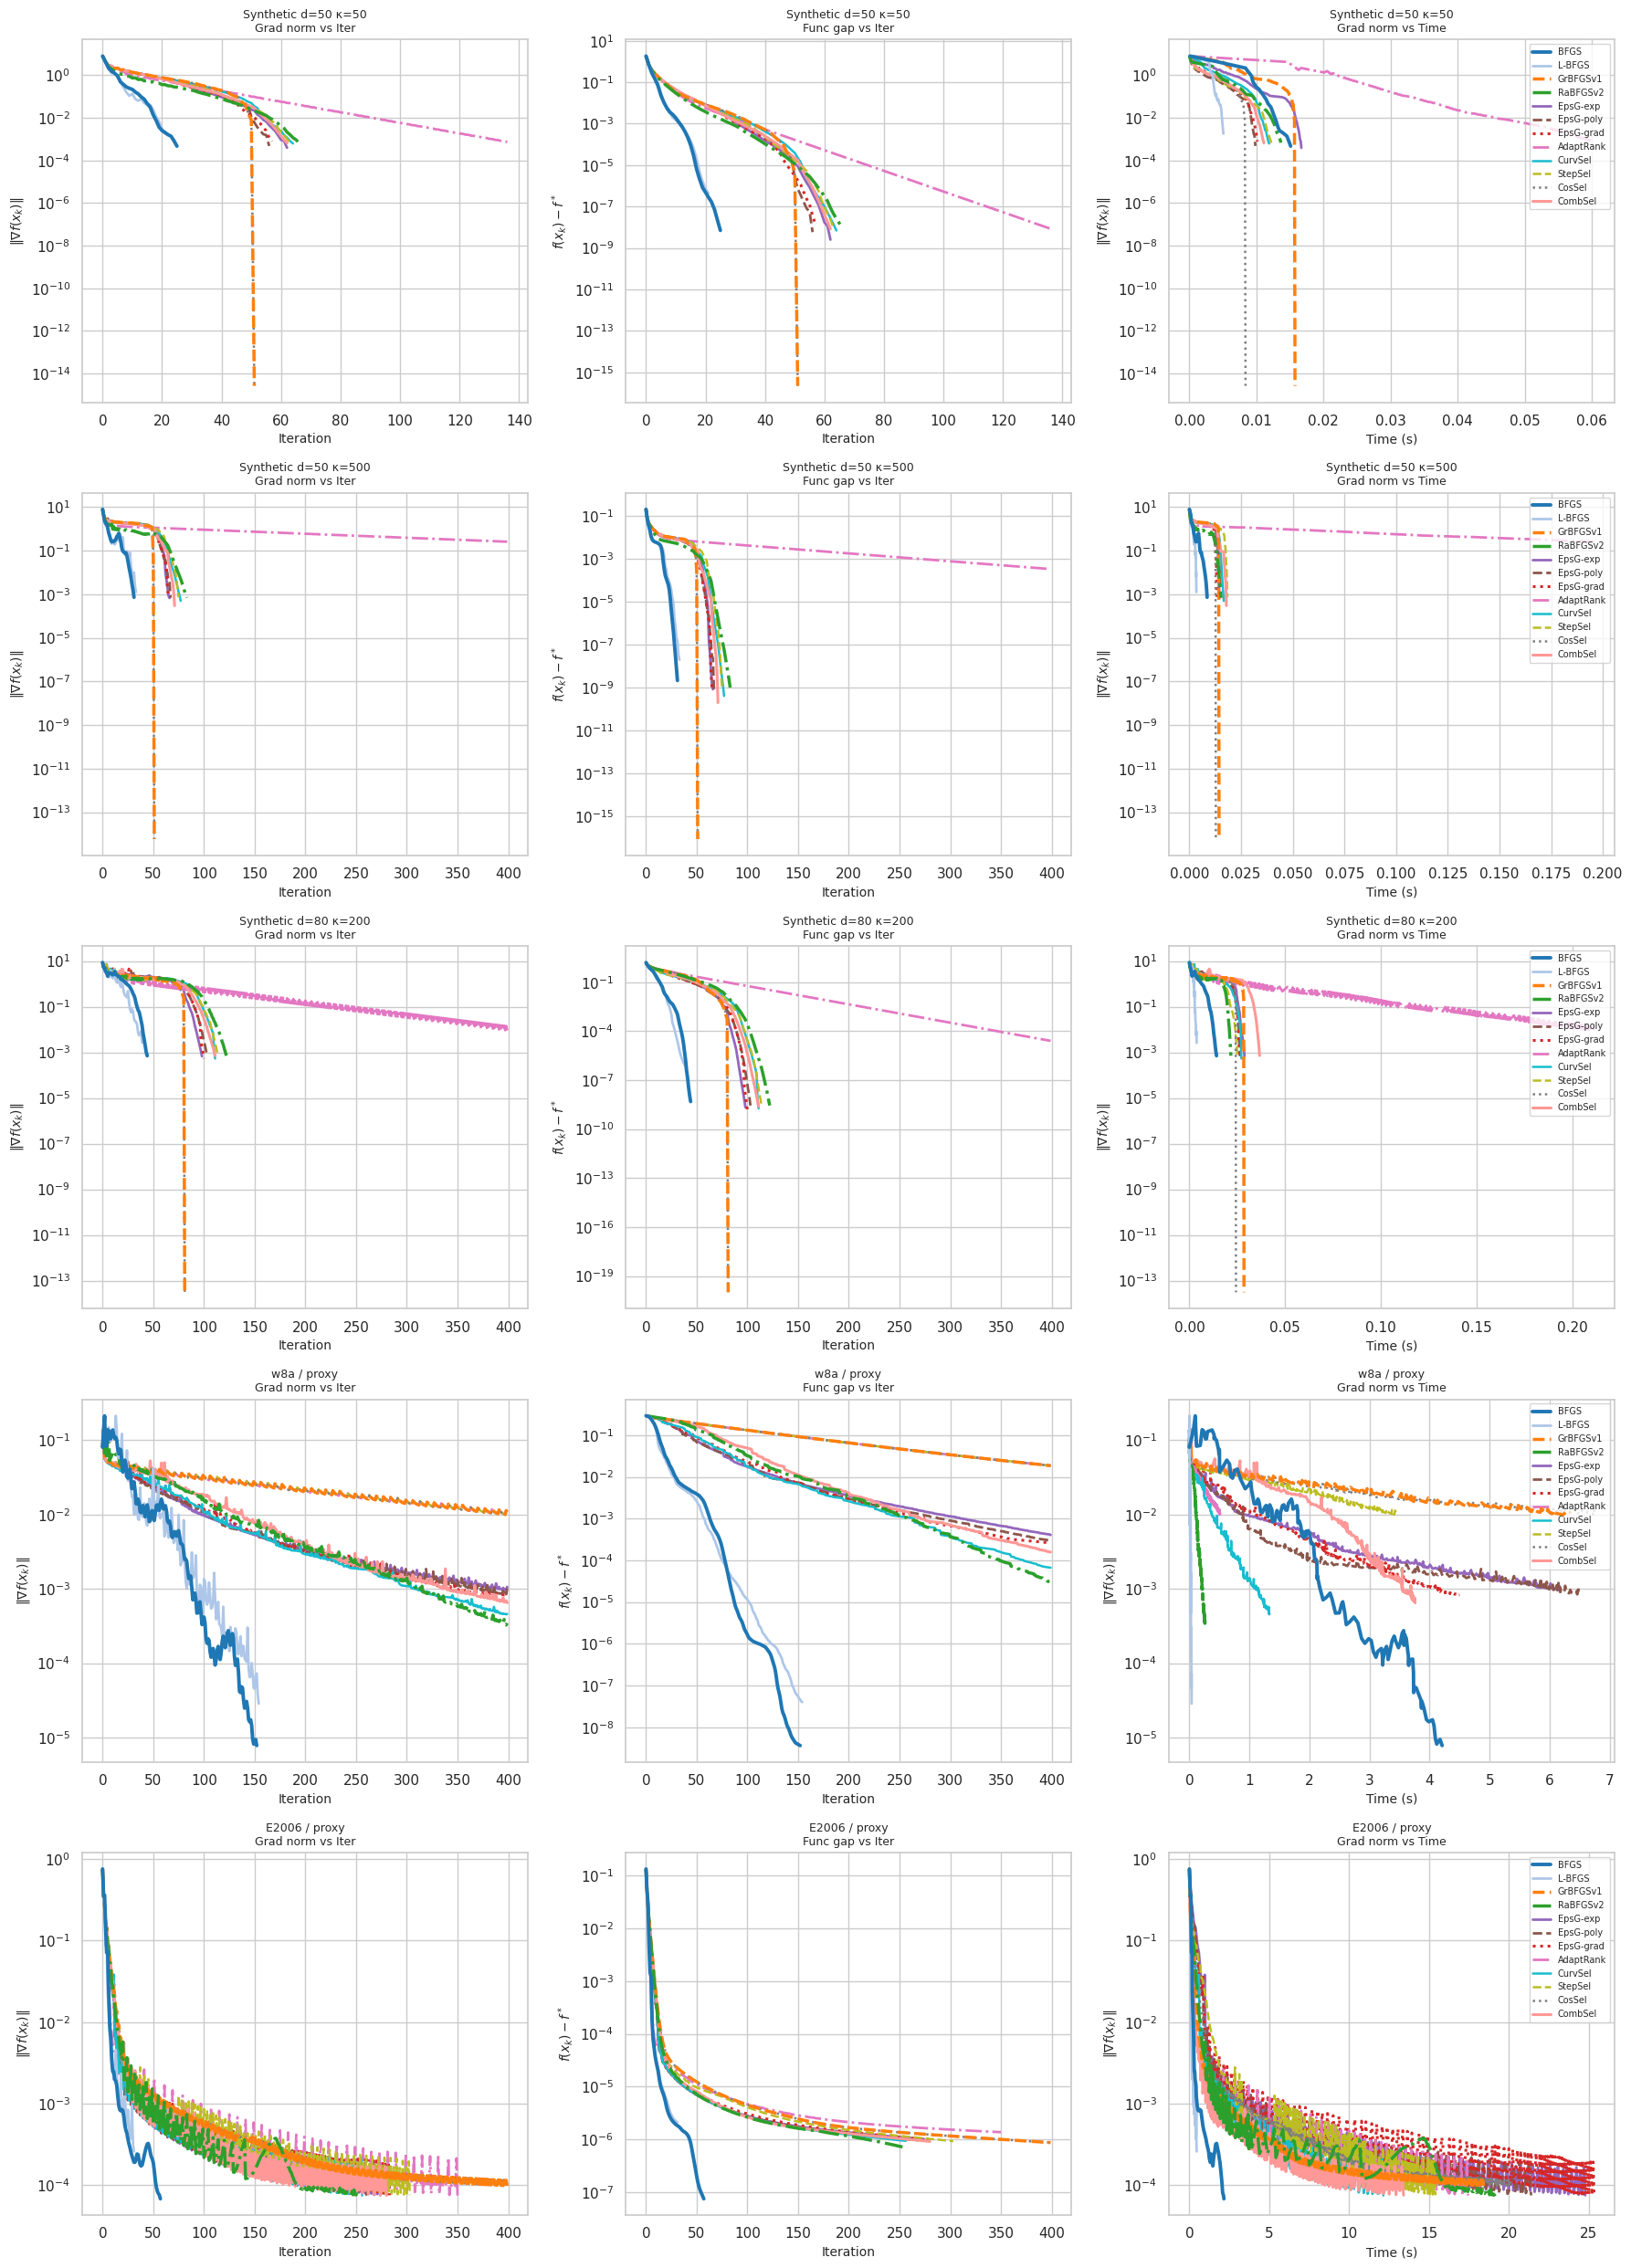


Method         | Synthetic d=50 κ | Synthetic d=50 κ | Synthetic d=80 κ |      w8a / proxy |    E2006 / proxy
------------------------------------------------------------------------------------------------------------------
BFGS           |               26 |               32 |               45 |              153 |               58
L-BFGS         |               22 |               34 |               40 |              155 |               32
GrBFGSv1       |               52 |               52 |               82 |              400 |              400
RaBFGSv2       |               67 |               84 |              123 |              400 |              254
EpsG-exp       |               63 |               67 |               99 |              400 |              275
EpsG-poly      |               57 |               68 |              104 |              400 |              269
EpsG-grad      |               58 |               66 |              101 |              400 |              284
Adap

In [9]:
def plot_experiment(results, fstar, title, axes_row):
    for col,(metric,xl,yl,pt) in enumerate([
        ('gn','Iteration', r'$\|\nabla f(x_k)\|$','Grad norm vs Iter'),
        ('fg','Iteration', r'$f(x_k)-f^*$',          'Func gap vs Iter'),
        ('t', 'Time (s)', r'$\|\nabla f(x_k)\|$', 'Grad norm vs Time'),
    ]):
        ax=axes_row[col]
        for name,h in results.items():
            sty=STYLES.get(name,dict(color='gray',ls='-',lw=1.5))
            if metric=='gn':  ax.semilogy(h['grad_norm'],**sty,label=name)
            elif metric=='fg': ax.semilogy([max(v-fstar,1e-20) for v in h['func']],**sty,label=name)
            else: ax.semilogy(h['time'],h['grad_norm'],**sty,label=name)
        ax.set_xlabel(xl,fontsize=10); ax.set_ylabel(yl,fontsize=10)
        ax.set_title(f'{title}\n{pt}',fontsize=9)
        if col==2: ax.legend(fontsize=7,ncol=1,loc='upper right')

fig,axes=plt.subplots(len(EXPERIMENTS),3,figsize=(18,5*len(EXPERIMENTS)))
for row,(label,data) in enumerate([(k,v) for k,v in ALL.items()]):
    plot_experiment(data['res'],data['fstar'],label,axes[row])
plt.tight_layout(); plt.savefig('fig1_main_comparison.png',dpi=130,bbox_inches='tight')
plt.show()

# Сводная таблица
print(f"\n{'Method':<14}", end='')
for label in ALL: print(f" | {label[:16]:>16}", end='')
print()
print('-'*(14+len(ALL)*20))
for name,_ in make_methods():
    print(f"{name:<14}", end='')
    for data in ALL.values(): print(f" | {len(data['res'][name]['func']):>16}", end='')
    print()

## 9. Анализ σ_A(G_k) vs теоретические оценки

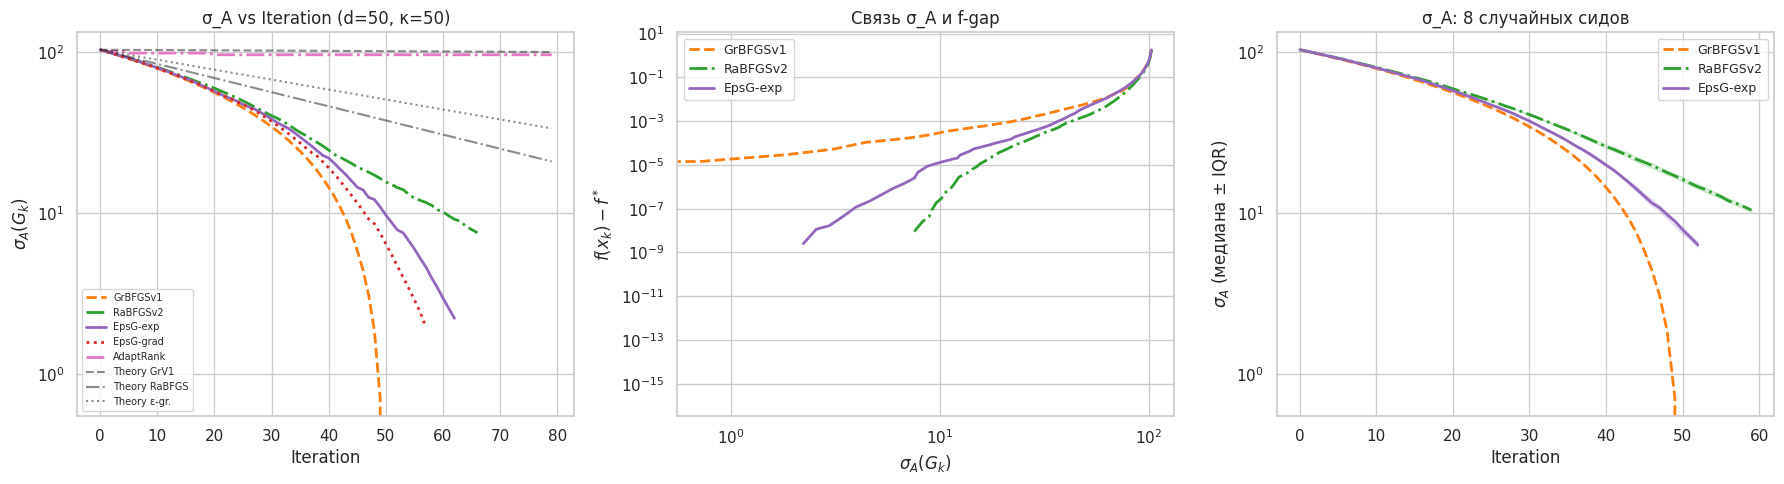

In [10]:
oracle_sa=oracle_s50k50; A_true=oracle_sa.A
d_sa,kappa_sa=50,50; x0_sa=np.zeros(d_sa)

sa_methods=[
    ('GrBFGSv1','#ff7f0e','--',lambda:GreedyV1Selector()),
    ('RaBFGSv2','#2ca02c','-.',lambda:RandomSelector()),
    ('EpsG-exp','#9467bd','-', lambda:EpsGreedySelector(0.7,'exponential',c=0.97)),
    ('EpsG-grad','#d62728',':', lambda:EpsGreedySelector(0.8,'gradient_adaptive',c=0.5)),
    ('AdaptRank','#e377c2','-.', lambda:AdaptiveRankSelector(1,8,0.99)),
]

fig,axes=plt.subplots(1,3,figsize=(18,5))

# Panel A: sigma_A vs iteration
ax=axes[0]
for name,clr,ls,Sel in sa_methods:
    _,_,h=QuasiNewton(oracle_sa,x0_sa,80,TOL,C1,C2,Sel(),seed=SEED,track_sigma=True)
    ax.semilogy(h['sigma_A'],color=clr,ls=ls,lw=2,label=name)
k_arr=np.arange(80); s0=compute_sigma_A(np.eye(d_sa),A_true)
ax.semilogy(s0*(1-1/(d_sa*kappa_sa))**k_arr,'k--',lw=1.5,alpha=0.5,label='Theory GrV1')
ax.semilogy(s0*(1-1/d_sa)**k_arr,'k-.',lw=1.5,alpha=0.5,label='Theory RaBFGS')
ax.semilogy(s0*(1-(1+(kappa_sa-1)*0.7)/(d_sa*kappa_sa))**k_arr,'k:',lw=1.5,alpha=0.5,label='Theory ε-gr.')
ax.set_xlabel('Iteration'); ax.set_ylabel(r'$\sigma_A(G_k)$')
ax.set_title(f'σ_A vs Iteration (d={d_sa}, κ={kappa_sa})'); ax.legend(fontsize=7)

# Panel B: coupling sigma_A ↔ f-gap
ax=axes[1]
fstar_sa=oracle_sa.func(xstar_s50k50)
for name,clr,ls,Sel in sa_methods[:3]:
    _,_,h=QuasiNewton(oracle_sa,x0_sa,80,TOL,C1,C2,Sel(),seed=SEED,track_sigma=True)
    fgap=[max(v-fstar_sa,1e-20) for v in h['func']]
    ax.loglog(h['sigma_A'],fgap,color=clr,ls=ls,lw=2,label=name)
ax.set_xlabel(r'$\sigma_A(G_k)$'); ax.set_ylabel(r'$f(x_k)-f^*$')
ax.set_title('Связь σ_A и f-gap'); ax.legend(fontsize=9)

# Panel C: медиана по 8 сидам
ax=axes[2]
for name,clr,ls,Sel in sa_methods[:3]:
    runs=[]
    for sd in range(8):
        _,_,h=QuasiNewton(oracle_sa,x0_sa,60,TOL,C1,C2,Sel(),seed=sd,track_sigma=True)
        runs.append(h['sigma_A'])
    ml=min(len(r) for r in runs); mat=np.array([r[:ml] for r in runs])
    med=np.median(mat,0); lo=np.percentile(mat,25,0); hi=np.percentile(mat,75,0)
    ax.semilogy(med,color=clr,ls=ls,lw=2,label=name)
    ax.fill_between(range(ml),lo,hi,color=clr,alpha=0.15)
ax.set_xlabel('Iteration'); ax.set_ylabel(r'$\sigma_A$ (медиана ± IQR)')
ax.set_title('σ_A: 8 случайных сидов'); ax.legend(fontsize=9)

plt.tight_layout(); plt.savefig('fig2_sigma_A.png',dpi=130,bbox_inches='tight'); plt.show()

## 10. Step-quality selectors: новые критерии переключения

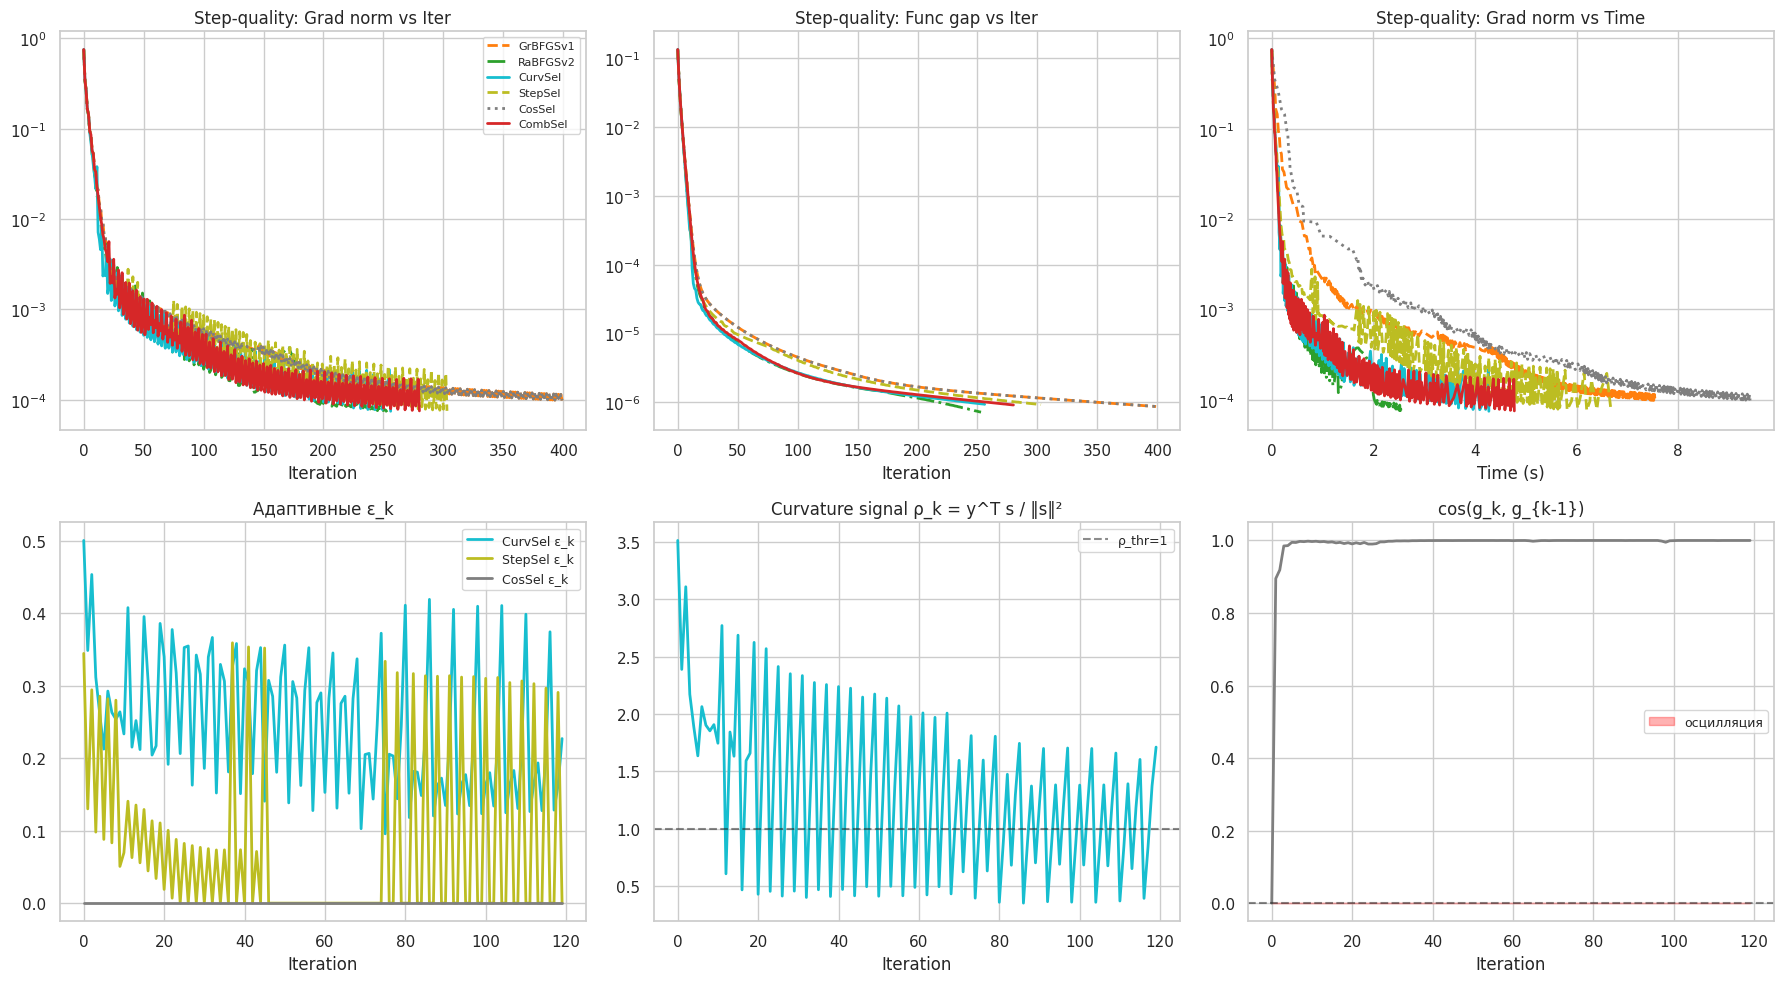

In [15]:
oracle_sq=oracle_e2006; fstar_sq=oracle_sq.func(xstar_e2006); x0_sq=np.zeros(300)

sq_list=[
    ('GrBFGSv1',  '#ff7f0e','--',lambda:GreedyV1Selector()),
    ('RaBFGSv2',  '#2ca02c','-.',lambda:RandomSelector()),
    ('CurvSel',   '#17becf','-', lambda:CurvatureSelector(0.8)),
    ('StepSel',   '#bcbd22','--',lambda:StepSizeSelector(0.8)),
    ('CosSel',    '#7f7f7f',':',  lambda:GradCosineSelector(0.8)),
    ('CombSel',   '#d62728','-', lambda:CombinedSelector(0.9)),
]
fig,axes=plt.subplots(2,3,figsize=(18,10))

for name,clr,ls,Sel in sq_list:
    _,_,h=QuasiNewton(oracle_sq,x0_sq,MI,TOL,C1,C2,Sel(),seed=SEED)
    axes[0,0].semilogy(h['grad_norm'],color=clr,ls=ls,lw=2,label=name)
    axes[0,1].semilogy([max(v-fstar_sq,1e-20) for v in h['func']],color=clr,ls=ls,lw=2,label=name)
    axes[0,2].semilogy(h['time'],h['grad_norm'],color=clr,ls=ls,lw=2,label=name)
for ax,t,xl in zip(axes[0],
    ['Grad norm vs Iter','Func gap vs Iter','Grad norm vs Time'],
    ['Iteration','Iteration','Time (s)']):
    ax.set_title(f'Step-quality: {t}'); ax.set_xlabel(xl)
axes[0,0].legend(fontsize=8)

s_curv=CurvatureSelector(0.8); s_step=StepSizeSelector(0.8); s_cos=GradCosineSelector(0.8)
for sel in [s_curv,s_step,s_cos]:
    QuasiNewton(oracle_sq,x0_sq,120,TOL,C1,C2,sel,seed=SEED)
axes[1,0].plot(s_curv.eps_history,'#17becf',lw=2,label='CurvSel ε_k')
axes[1,0].plot(s_step.eps_history,'#bcbd22',lw=2,label='StepSel ε_k')
axes[1,0].plot(s_cos.eps_history,'#7f7f7f',lw=2,label='CosSel ε_k')
axes[1,0].set_title('Адаптивные ε_k'); axes[1,0].legend(fontsize=9); axes[1,0].set_xlabel('Iteration')
axes[1,1].plot(s_curv.rho_history,'#17becf',lw=2)
axes[1,1].axhline(1,color='k',ls='--',alpha=0.5,label='ρ_thr=1')
axes[1,1].set_title('Curvature signal ρ_k = y^T s / ‖s‖²')
axes[1,1].legend(fontsize=9); axes[1,1].set_xlabel('Iteration')
axes[1,2].plot(s_cos.cos_history,'#7f7f7f',lw=2)
axes[1,2].axhline(0,color='k',ls='--',alpha=0.5)
axes[1,2].fill_between(range(len(s_cos.cos_history)),[min(c,0) for c in s_cos.cos_history],
                        0,color='red',alpha=0.3,label='осцилляция')
axes[1,2].set_title('cos(g_k, g_{k-1})'); axes[1,2].legend(fontsize=9); axes[1,2].set_xlabel('Iteration')
plt.tight_layout(); plt.savefig('fig3_step_quality.png',dpi=130,bbox_inches='tight'); plt.show()

## 11. Нейронная сеть: MLP на sklearn digits (4 класса)

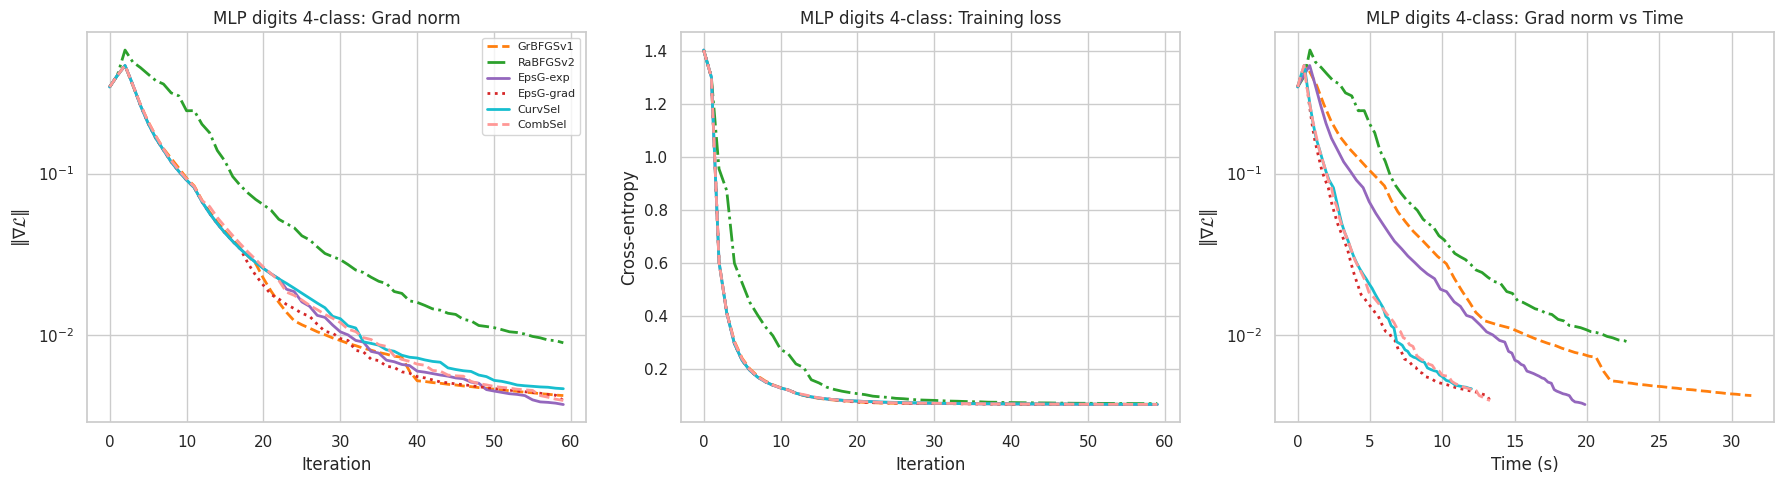


Method          Train acc   Test acc       Loss   Iters
-------------------------------------------------------
GrBFGSv1            1.000      1.000     0.0685      60
RaBFGSv2            1.000      1.000     0.0712      60
EpsG-exp            1.000      1.000     0.0679      60
EpsG-grad           1.000      1.000     0.0682      60
CurvSel             1.000      1.000     0.0688      60
CombSel             1.000      1.000     0.0683      60


In [12]:
mlp_methods=[
    ('GrBFGSv1','#ff7f0e','--',lambda:GreedyV1Selector()),
    ('RaBFGSv2','#2ca02c','-.',lambda:RandomSelector()),
    ('EpsG-exp','#9467bd','-', lambda:EpsGreedySelector(0.7,'exponential',c=0.97)),
    ('EpsG-grad','#d62728',':', lambda:EpsGreedySelector(0.8,'gradient_adaptive',c=0.5)),
    ('CurvSel', '#17becf','-', lambda:CurvatureSelector(0.8)),
    ('CombSel', '#ff9896','--',lambda:CombinedSelector(0.9))
]

fig,axes=plt.subplots(1,3,figsize=(18,5))
mlp_res={}
for name,clr,ls,Sel in mlp_methods:
    ws,fs,hm=QuasiNewton(mlp_oracle,w_mlp0,60,1e-5,C1,C2,Sel(),seed=SEED)
    mlp_res[name]={'h':hm,'acc_tr':mlp_oracle.accuracy(ws),
                   'acc_te':mlp_oracle.accuracy(ws,Xd_te,yd_te),'loss':fs,'iters':len(hm['func'])}
    axes[0].semilogy(hm['grad_norm'],color=clr,ls=ls,lw=2,label=name)
    axes[1].plot(hm['func'],       color=clr,ls=ls,lw=2,label=name)
    axes[2].semilogy(hm['time'],hm['grad_norm'],color=clr,ls=ls,lw=2,label=name)

for ax,t,xl,yl in zip(axes,
    ['Grad norm','Training loss','Grad norm vs Time'],
    ['Iteration','Iteration','Time (s)'],
    [r'$\|\nabla\mathcal{L}\|$','Cross-entropy',r'$\|\nabla\mathcal{L}\|$']):
    ax.set_title(f'MLP digits 4-class: {t}'); ax.set_xlabel(xl); ax.set_ylabel(yl)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig('fig4_mlp.png',dpi=130,bbox_inches='tight'); plt.show()

print(f"\n{'Method':<14} {'Train acc':>10} {'Test acc':>10} {'Loss':>10} {'Iters':>7}")
print('-'*55)
for n,r in mlp_res.items():
    print(f"{n:<14} {r['acc_tr']:>10.3f} {r['acc_te']:>10.3f} {r['loss']:>10.4f} {r['iters']:>7}")

## 12. Анализ чувствительности гиперпараметров

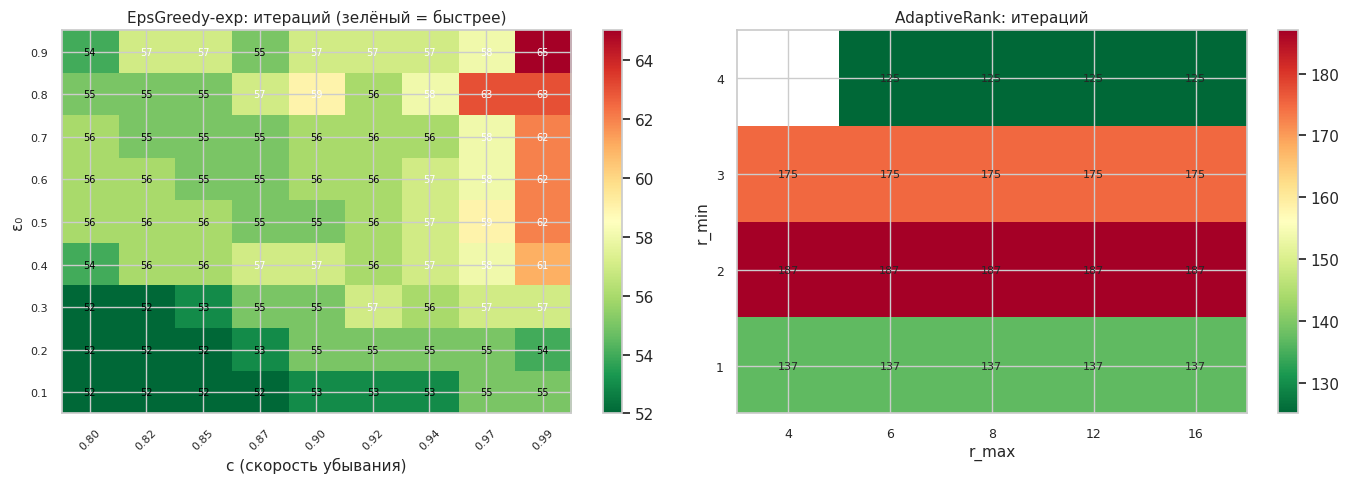

Лучшие гиперпараметры EpsGreedy-exp: ε₀=0.1, c=0.80 → 52 итераций


In [13]:
oracle_sv=oracle_s50k50; x0_sv=np.zeros(50)

# Grid EpsGreedy-exp: eps_0 x c
eps0_v=np.linspace(0.1,0.9,9); c_v=np.linspace(0.80,0.99,9)
g_eps=np.zeros((len(eps0_v),len(c_v)))
for i,e0 in enumerate(eps0_v):
    for j,cv in enumerate(c_v):
        _,_,h=QuasiNewton(oracle_sv,x0_sv,300,TOL,C1,C2,
                           EpsGreedySelector(e0,'exponential',c=cv),seed=SEED)
        g_eps[i,j]=len(h['func'])

# Grid AdaptRank: r_min x r_max
rmin_v=[1,2,3,4]; rmax_v=[4,6,8,12,16]
g_rank=np.full((len(rmin_v),len(rmax_v)),np.nan)
for i,rm in enumerate(rmin_v):
    for j,rx in enumerate(rmax_v):
        if rm>=rx: continue
        _,_,h=QuasiNewton(oracle_sv,x0_sv,400,TOL,C1,C2,
                           AdaptiveRankSelector(rm,rx,0.99),seed=SEED)
        g_rank[i,j]=len(h['func'])

fig,axes=plt.subplots(1,2,figsize=(14,5))
im0=axes[0].imshow(g_eps,aspect='auto',cmap='RdYlGn_r',origin='lower')
axes[0].set_xticks(range(len(c_v))); axes[0].set_xticklabels([f'{c:.2f}' for c in c_v],fontsize=8,rotation=45)
axes[0].set_yticks(range(len(eps0_v))); axes[0].set_yticklabels([f'{e:.1f}' for e in eps0_v],fontsize=8)
axes[0].set_xlabel('c (скорость убывания)',fontsize=11); axes[0].set_ylabel('ε₀',fontsize=11)
axes[0].set_title('EpsGreedy-exp: итераций (зелёный = быстрее)',fontsize=11)
plt.colorbar(im0,ax=axes[0])
for i in range(len(eps0_v)):
    for j in range(len(c_v)):
        clr='white' if g_eps[i,j]>g_eps.mean() else 'black'
        axes[0].text(j,i,f'{int(g_eps[i,j])}',ha='center',va='center',fontsize=7,color=clr)

masked=np.ma.masked_invalid(g_rank)
im1=axes[1].imshow(masked,aspect='auto',cmap='RdYlGn_r',origin='lower')
axes[1].set_xticks(range(len(rmax_v))); axes[1].set_xticklabels(rmax_v,fontsize=9)
axes[1].set_yticks(range(len(rmin_v))); axes[1].set_yticklabels(rmin_v,fontsize=9)
axes[1].set_xlabel('r_max',fontsize=11); axes[1].set_ylabel('r_min',fontsize=11)
axes[1].set_title('AdaptiveRank: итераций',fontsize=11)
plt.colorbar(im1,ax=axes[1])
for i in range(len(rmin_v)):
    for j in range(len(rmax_v)):
        if not np.isnan(g_rank[i,j]):
            axes[1].text(j,i,f'{int(g_rank[i,j])}',ha='center',va='center',fontsize=8)

plt.tight_layout(); plt.savefig('fig5_sensitivity.png',dpi=130,bbox_inches='tight'); plt.show()

# Рекомендуемые гиперпараметры
best_ij=np.unravel_index(np.argmin(g_eps),g_eps.shape)
print(f"Лучшие гиперпараметры EpsGreedy-exp: ε₀={eps0_v[best_ij[0]]:.1f}, c={c_v[best_ij[1]]:.2f} → {int(g_eps[best_ij])} итераций")

### Литература
- Lin, Ye, Zhang. *Explicit Convergence Rates of Greedy and Random Quasi-Newton Methods*. JMLR 23 (2022).
- Rodomanov, Nesterov. *Greedy quasi-Newton methods with explicit superlinear convergence*. SIAM JO (2021).
- Halko, Martinsson, Tropp. *Finding structure with randomness*. SIAM Review (2011).